# 1. Install dependencies and setup

In [2]:
!pip install tensorflow opencv-python matplotlib

In [1]:
!pip list

Package                              Version
------------------------------------ -----------
absl-py                              2.5.0
action-msgs                          1.2.3
action-tutorials-interfaces          0.20.9
action-tutorials-py                  0.20.9
actionlib-msgs                       4.9.1
actuator-msgs                        0.0.1
ament-cmake-test                     1.3.14
ament-copyright                      0.12.15
ament-cppcheck                       0.12.15
ament-cpplint                        0.12.15
ament-flake8                         0.12.15
ament-index-python                   1.4.1
ament-lint                           0.12.15
ament-lint-cmake                     0.12.15
ament-package                        0.14.2
ament-pep257                         0.12.15
ament-uncrustify                     0.12.15
ament-xmllint                        0.12.15
angles                               1.15.0
anyio                                4.14.2
argon2-cffi           

In [1]:
import tensorflow as tf
import os
import cv2
import matplotlib.pyplot as plt
import filetype

I0000 00:00:1785597385.760095   52094 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785597385.761004   52094 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785597385.794867   52094 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785597386.675101   52094 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

# 2. Cleaning up dirty files

In [2]:
os.path.join('data', 'happy')
data_dir = 'data'
img_exts = ['jpeg', 'jpg', 'bmp', 'png']

In [3]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        img_path = os.path.join(data_dir, image_class, image)

        kind = filetype.guess(img_path)

        if kind is None: 
            print(f"Unknown file type: {img_path}")
            os.remove(img_path)
            continue

        if kind.extension not in img_exts:
            print(f"Unsupported format! {img_path}")
            os.remove(img_path)
            continue

        img = cv2.imread(img_path)

        if img is None:
            print(f"Corrupted or unreadable image {img_path}")
            os.remove(img_path)
            continue

# 3. Loading the data

In [4]:
import numpy as np

In [5]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 113 files belonging to 2 classes.


E0000 00:00:1785597398.447505   52094 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [6]:
data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()
print(batch[0].max())
print(batch[0].min())

255.0
0.0


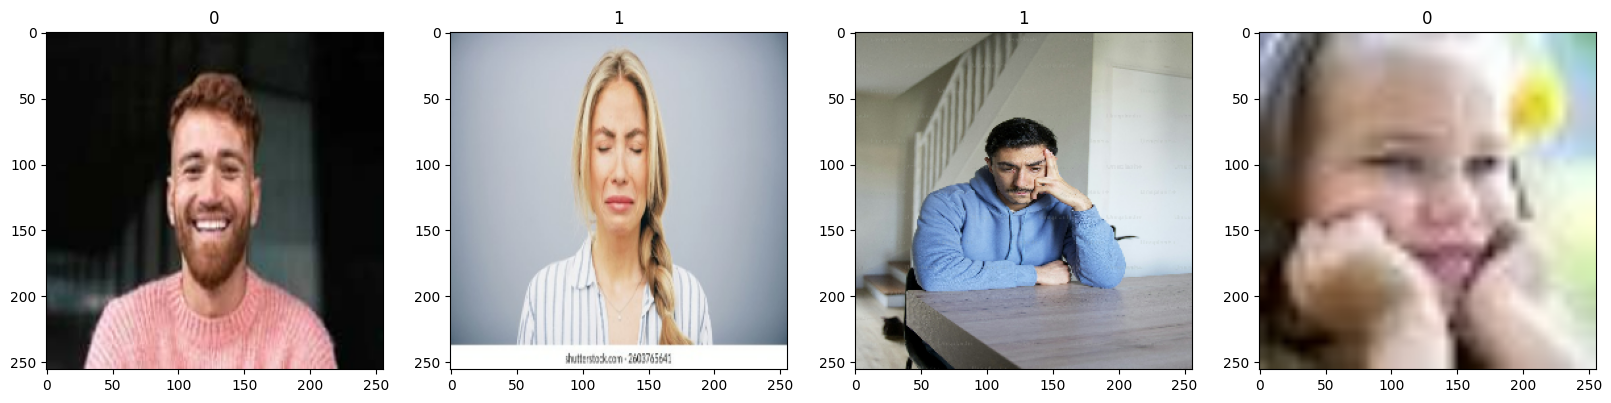

In [13]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# 4. Scaling the data

In [10]:
data = data.map(lambda x, y: (x/255, y))
data.as_numpy_iterator().next()[0].min()

np.float32(0.0)

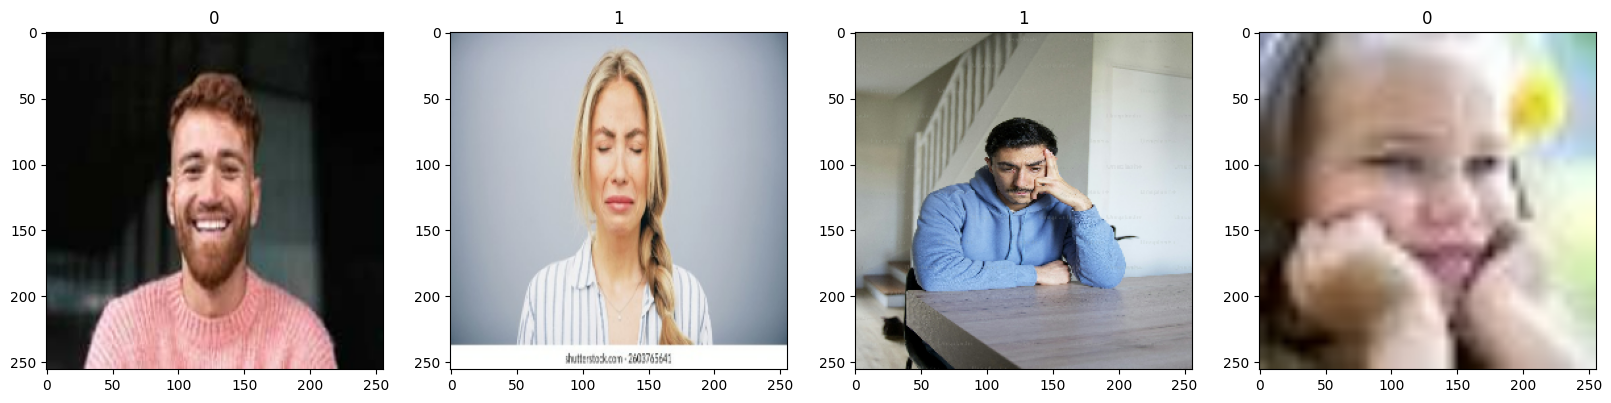

In [15]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# 5. Split the data

In [16]:
len(data)

4

In [17]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)+1
test_size = int(len(data)*.1)+1

In [18]:
print(train_size, val_size, test_size)

2 1 1


In [19]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [20]:
print(len(test), len(val), len(train))

1 1 2


# 6. Building the model

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [25]:
model = Sequential()

In [26]:
model.add(Conv2D(16, (3,3), 1, activation = 'relu', input_shape = (256, 256, 3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), 1, activation = 'relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3,3), 1, activation = 'relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

/home/sru/Programs/image_classifier/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.compile('adam', loss = tf.losses.BinaryCrossentropy(), metrics = ['accuracy'])

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

# Training & Visualization

In [36]:
logdir = 'logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = logdir)

In [39]:
hist = model.fit(train, epochs = 20, validation_data = val, callbacks = [tensorboard_callback])

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 465ms/step - accuracy: 0.5000 - loss: 0.8010 - val_accuracy: 0.5312 - val_loss: 0.6062
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 382ms/step - accuracy: 0.5938 - loss: 0.6111 - val_accuracy: 0.7188 - val_loss: 0.5684
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 444ms/step - accuracy: 0.7656 - loss: 0.5184 - val_accuracy: 0.8438 - val_loss: 0.4118
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 443ms/step - accuracy: 0.7500 - loss: 0.5324 - val_accuracy: 0.7500 - val_loss: 0.4912
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 368ms/step - accuracy: 0.8281 - loss: 0.3960 - val_accuracy: 0.7812 - val_loss: 0.3899
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 439ms/step - accuracy: 0.7656 - loss: 0.4112 - val_accuracy: 0.8438 - val_loss: 0.2990
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 361ms/step - accuracy: 0.8750 - loss: 0.3216 - val_accuracy: 0.7500 - val_loss: 0.4882
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step - accuracy: 0.7500 - loss: 0.3853 - val_accuracy: 0.8750 - val_loss:

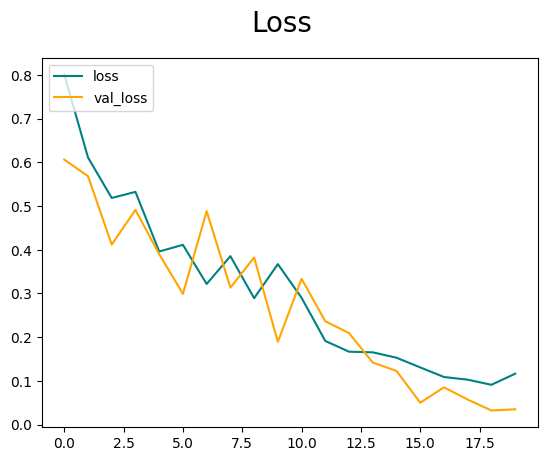

In [40]:
fig = plt.figure()
plt.plot(hist.history['loss'], color = 'teal', label = 'loss')
plt.plot(hist.history['val_loss'], color = 'orange', label = 'val_loss')
fig.suptitle('Loss', fontsize = 20)
plt.legend(loc = "upper left")
plt.show()

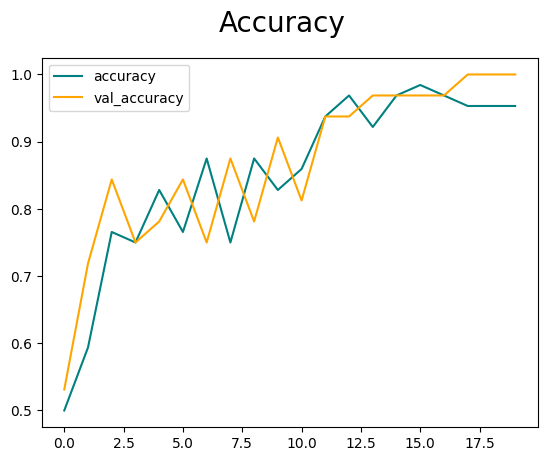

In [41]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color = 'teal', label = 'accuracy')
plt.plot(hist.history['val_accuracy'], color = 'orange', label = 'val_accuracy')
fig.suptitle('Accuracy', fontsize = 20)
plt.legend(loc = "upper left")
plt.show()

# EVALUATION

In [42]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [43]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [44]:
for batch in test.as_numpy_iterator():
    x, y = batch
    yhat = model.predict(x)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


In [45]:
print(f'Precision: {pre.result().numpy()}, Recall: {re.result().numpy()}, Accuracy: {acc.result().numpy()}')

Precision: 1.0, Recall: 1.0, Accuracy: 1.0


# TESTING 

In [68]:
img = cv2.imread("data/sad/sad_test.jpeg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

resize = tf.image.resize(img, (256,256))

yhat = model.predict(np.expand_dims(resize/255.0, 0))
print(yhat)

if yhat > 0.5:
    print('Sad!')
else:
    print('Happy')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[0.11324415]]
Happy
